# Differentially Private SVM - Lung Cancer Dataset

Implements DP-SVM with Huber loss and objective perturbation
(Chaudhuri, Monteleoni & Sarwate, JMLR 2011, Algorithm 2) for multi-class via One-vs-Rest,
using the shared `DPSVMOneVsRest` from `common_svm.py`.

Features are L2-normalized inside the model (`normalize=True`) so that every training row
satisfies ||x_i|| <= 1, the privacy precondition for the sensitivity bound in Algorithm 2.

ε ∈ {0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0}, 30 runs each.


In [1]:
import time
import os
import sys
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')

# The DP-SVM implementation and the model exporter are shared across all
# datasets and live at the repository root.
REPO_ROOT = os.path.abspath(os.path.join('..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from common_svm import DPSVMOneVsRest  # noqa: E402
from model_exporter import export_model  # noqa: E402

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']
n_classes = data.get('n_classes', 3)

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Classes:      {sorted(set(y_train))}")
print(f"n_classes:    {n_classes}")


Training set: (40000, 23)
Test set:     (10000, 23)
Classes:      [np.int64(0), np.int64(1), np.int64(2)]
n_classes:    3


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('./output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_SVM.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline Accuracy: 1.0000
Baseline F1-Score: 1.0000


## 4. DP-SVM Implementation (One-vs-Rest)

**Implementation:** `DifferentiallyPrivateSVM` / `DPSVMOneVsRest` from `common_svm.py` at the repository root — a single shared implementation of Algorithm 2 (Chaudhuri, Monteleoni & Sarwate, JMLR 2011) used by every dataset.

`normalize=True` deterministically projects each record onto the unit L2 ball, x → x / max(1, ‖x‖₂), so the privacy precondition ‖x_i‖₂ ≤ 1 holds. The same record-wise projection is applied at inference.

`fit_intercept=False` fixes the intercept at zero in every one-vs-rest classifier, so every optimized parameter is L2-regularized and each objective satisfies the theorem's strong-convexity setting; noise is drawn in d = n_features dimensions.

`privacy_report()` records ε′, Δ and whether Algorithm 2's fallback branch fired. When it does, the effective budget is ε/2 rather than ε — the sweep below stores this per ε in the JSON report. For One-vs-Rest the budget is split evenly across the m binary classifiers, so each is trained at ε/m.


## 5. Quick Demo at ε=1.0 (30 Runs)

In [4]:
epsilon = 1.0
N_RUNS  = 30
detail_accuracies  = []
detail_f1s         = []
detail_precisions  = []
detail_recalls     = []

print(f"Training DP-SVM (OvR) {N_RUNS} times with epsilon={epsilon}...")
print('=' * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed   = run * 10 + 42
    dp_svm = DPSVMOneVsRest(epsilon=epsilon, Lambda=0.01, h=0.5,
                            fit_intercept=False, normalize=True,
                            random_state=seed)
    _t0 = time.perf_counter()
    dp_svm.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_pred = dp_svm.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    detail_extra.add(y_test, y_pred, model=dp_svm, X=X_test, train_time=train_time)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

print('=' * 60)
print(f"\nMean Accuracy: {np.mean(detail_accuracies):.4f} +/- {np.std(detail_accuracies):.4f}")
print(f"Mean F1-Score: {np.mean(detail_f1s):.4f} +/- {np.std(detail_f1s):.4f}")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP-SVM (OvR) 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run  2/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run  3/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387


  Run  4/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run  5/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run  6/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run  7/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398


  Run  8/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run  9/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run 10/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run 11/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398


  Run 12/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run 13/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 14/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 15/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398


  Run 16/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 17/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 18/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run 19/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398


  Run 20/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run 21/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 22/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 23/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387


  Run 24/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 25/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 26/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398
  Run 27/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398


  Run 28/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 29/30 | Acc: 0.9387 | F1: 0.9370 | Prec: 0.9436 | Rec: 0.9387
  Run 30/30 | Acc: 0.9398 | F1: 0.9381 | Prec: 0.9450 | Rec: 0.9398

Mean Accuracy: 0.9392 +/- 0.0005
Mean F1-Score: 0.9376 +/- 0.0005
Added metrics over the detail runs:
  Balanced Acc:   0.9384 ± 0.0006
  AUROC:          0.9794 ± 0.0004
  Train Time (s): 0.0490 ± 0.0019


## 6. Full Sweep Across All Epsilon Values

In [5]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
N_RUNS = 30

results = {
    'epsilon': [], 'accuracy_mean': [], 'accuracy_std': [],
    'f1_score_mean': [], 'f1_score_std': [],
    'precision_mean': [], 'precision_std': [],
    'recall_mean': [], 'recall_std': [],
}

all_results = {
    'model_type': 'Differentially Private SVM (Algorithm 2, Huber Loss + OvR)',
    'dataset': 'Lung Cancer',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'n_classes': n_classes,
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP-SVM (Algorithm 2) with {N_RUNS} runs per epsilon...")
print('=' * 80)

for eps in epsilon_values:
    run_accs, run_f1s, run_precs, run_recs, run_cms = [], [], [], [], []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed   = run * 10 + 42
        dp_svm = DPSVMOneVsRest(epsilon=eps, Lambda=0.01, h=0.5,
                                fit_intercept=False, normalize=True,
                                random_state=seed)
        _t0 = time.perf_counter()
        dp_svm.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_svm.predict(X_test)
        run_accs.append(accuracy_score(y_test, y_pred))
        extra.add(y_test, y_pred, model=dp_svm, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        run_precs.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        run_recs.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        run_cms.append(confusion_matrix(y_test, y_pred).tolist())
        if run == 0:
            export_model(dp_svm, f'output/model/dp_svm_model_eps_{eps}.pkl')
            privacy = dp_svm.privacy_report()

    acc_mean,  acc_std  = np.mean(run_accs),  np.std(run_accs)
    f1_mean,   f1_std   = np.mean(run_f1s),   np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precs), np.std(run_precs)
    rec_mean,  rec_std  = np.mean(run_recs),  np.std(run_recs)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    all_results['epsilon_results'][str(eps)] = {
        'epsilon': float(eps), 'n_runs': N_RUNS,
        'accuracy_mean': acc_mean, 'accuracy_std': acc_std,
        'f1_mean': f1_mean, 'f1_std': f1_std,
        'precision_mean': prec_mean, 'precision_std': prec_std,
        'recall_mean': rec_mean, 'recall_std': rec_std,
        'per_run_accuracies': run_accs, 'per_run_f1s': run_f1s,
        'per_run_confusion_matrices': run_cms,
        'privacy': privacy,
    }
    all_results['epsilon_results'][str(eps)].update(extra.summary())
    all_results['epsilon_results'][str(eps)].update(extra.per_run())

    print(f"eps={eps:5.2f} | Acc: {acc_mean:.4f}+/-{acc_std:.4f} | F1: {f1_mean:.4f}+/-{f1_std:.4f}")

    if privacy['any_fallback_triggered']:
        print(f"        Algorithm 2 fallback fired for at least one of the"
              f" {privacy['n_classifiers']} OvR classifiers"
              f" (\u03b5 per classifier = {privacy['epsilon_per_classifier']:.4f})")

print('=' * 80)
print('Training complete!')


Training DP-SVM (Algorithm 2) with 30 runs per epsilon...


Model successfully exported to output/model/dp_svm_model_eps_0.1.pkl


eps= 0.10 | Acc: 0.9319+/-0.0174 | F1: 0.9303+/-0.0182
Model successfully exported to output/model/dp_svm_model_eps_0.2.pkl


eps= 0.20 | Acc: 0.9383+/-0.0078 | F1: 0.9367+/-0.0081
Model successfully exported to output/model/dp_svm_model_eps_0.4.pkl


eps= 0.40 | Acc: 0.9389+/-0.0020 | F1: 0.9372+/-0.0021
Model successfully exported to output/model/dp_svm_model_eps_0.6.pkl


...

eps= 2.00 | Acc: 0.9394+/-0.0005 | F1: 0.9377+/-0.0005
Model successfully exported to output/model/dp_svm_model_eps_4.0.pkl


eps= 4.00 | Acc: 0.9396+/-0.0004 | F1: 0.9379+/-0.0004
Model successfully exported to output/model/dp_svm_model_eps_6.0.pkl


eps= 6.00 | Acc: 0.9397+/-0.0004 | F1: 0.9380+/-0.0004
Model successfully exported to output/model/dp_svm_model_eps_8.0.pkl


eps= 8.00 | Acc: 0.9398+/-0.0002 | F1: 0.9381+/-0.0002
Model successfully exported to output/model/dp_svm_model_eps_10.0.pkl


eps=10.00 | Acc: 0.9398+/-0.0000 | F1: 0.9381+/-0.0000
Training complete!


## 7. Results Summary

In [6]:
results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = 1 - results_df['accuracy_mean'] / baseline_accuracy
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
print(results_df.to_string(index=False))

 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean   recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.931890  1.742308e-02       0.930316  1.816532e-02        0.936805   1.603544e-02     0.931890 1.742308e-02                0.930617           1.771528e-02      0.977561     0.003834         0.066856        0.006351            0.068110           6.811000
     0.2       0.938260  7.792244e-03       0.936746  8.108850e-03        0.943494   7.115566e-03     0.938260 7.792244e-03                0.937273           8.010968e-03      0.979289     0.001859         0.060505        0.008753            0.061740           6.174000
     0.4       0.938873  2.000655e-03       0.937206  2.136220e-03        0.944047   1.839645e-03     0.938873 2.000655e-03                0.938034           2.048222e-03      0.979491     0

## 8. Save Results

In [7]:
os.makedirs('output', exist_ok=True)
with open('./output/dp_svm_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)
results_df.to_csv('./output/dp_results.csv', index=False)
print('Results saved to output/')

Results saved to output/


## 9. Visualization

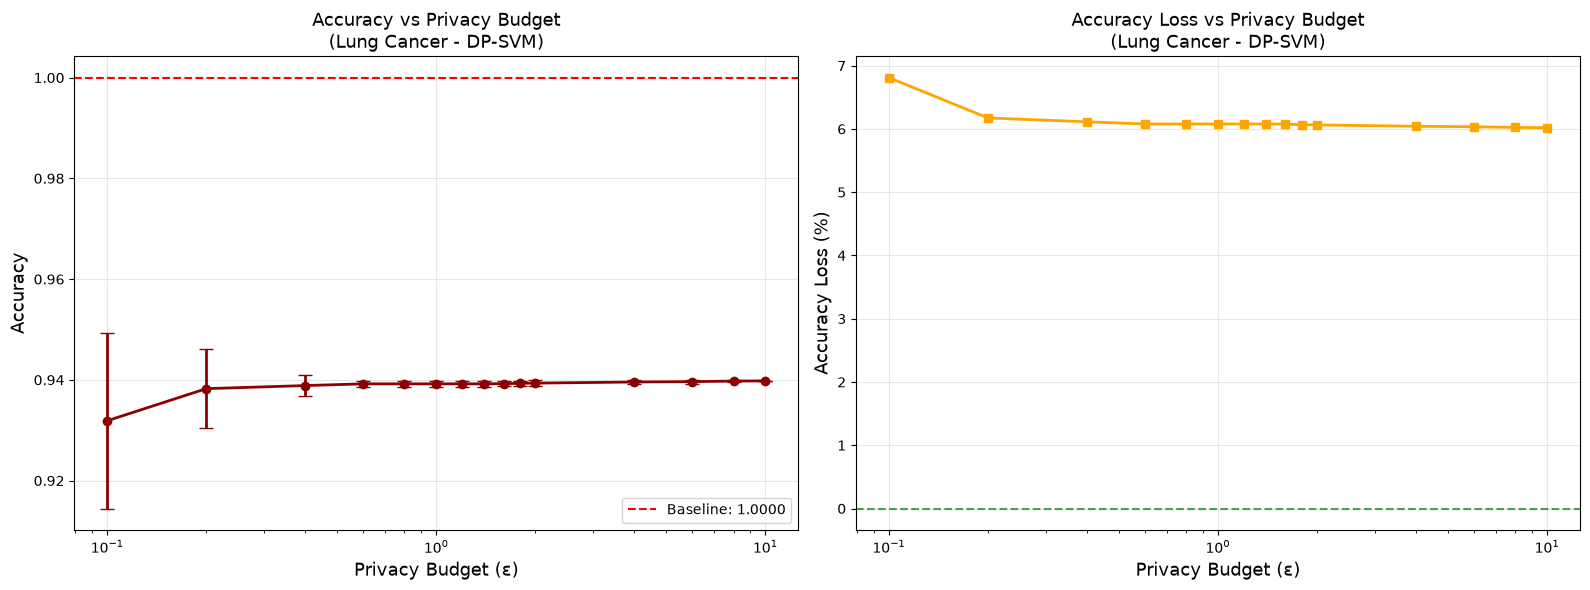

Plot saved to ./output/dp_svm_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'], marker='o', capsize=5, linewidth=2, color='darkred')
if baseline_accuracy is not None:
    axes[0].axhline(y=baseline_accuracy, color='red', linestyle='--',
                    label=f'Baseline: {baseline_accuracy:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Privacy Budget (ε)', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy vs Privacy Budget\n(Lung Cancer - DP-SVM)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if 'accuracy_loss_pct' in results_df.columns:
    axes[1].plot(results_df['epsilon'], results_df['accuracy_loss_pct'], marker='s', linewidth=2, color='orange')
    axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.7)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Privacy Budget (ε)', fontsize=13)
    axes[1].set_ylabel('Accuracy Loss (%)', fontsize=13)
    axes[1].set_title('Accuracy Loss vs Privacy Budget\n(Lung Cancer - DP-SVM)', fontsize=13)
    axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./output/dp_svm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ./output/dp_svm_comparison.png')